# 🔷 CAP 1 — Recolección

In [39]:
# Importamos las librerías necesarias para el análisis y el modelado
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import chi2
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier


In [40]:
"""
# Montamos Google Drive para acceder al archivo de datos
from google.colab import drive
drive.mount('/content/drive')
"""

"\n# Montamos Google Drive para acceder al archivo de datos\nfrom google.colab import drive\ndrive.mount('/content/drive')\n"

In [41]:
# Cargamos el dataset tratado y revisamos las primeras filas.
# Opción 1 — Google Drive (Colab con Drive montado):
#df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Telecom x parte 2/datos_tratados.csv')

# Opción 2 — Colab / local (CSV en la misma carpeta o subido a /content/):
df = pd.read_csv('datos_tratados.csv')
df.head()


,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [42]:
# Exploramos la estructura y tipos de datos del dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


# 🔷 CAP 2 — EDA (Análisis Exploratorio de Datos)

## 2.1 Proporción de Churn


In [43]:
# Verificamos la proporción de churn y el desbalance de clases
print(df['Churn'].value_counts(normalize=True) * 100)


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


## 2.2 Correlación entre variables numéricas

In [44]:
# Creamos una copia numérica e incluimos Churn como variable binaria
df_numeric = df.select_dtypes(include=["int64", "float64"]).copy()
df_numeric["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})


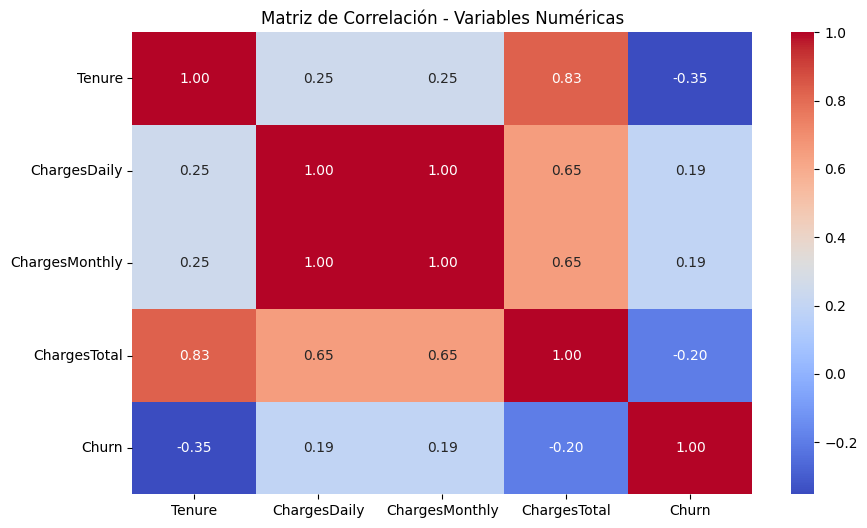

In [45]:
# Graficamos la matriz de correlación entre variables numéricas
corr_matrix = df_numeric.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variables Numéricas")
plt.show()


## 2.3 Análisis dirigido: Tenure, ChargesMonthly y ChargesTotal vs Churn

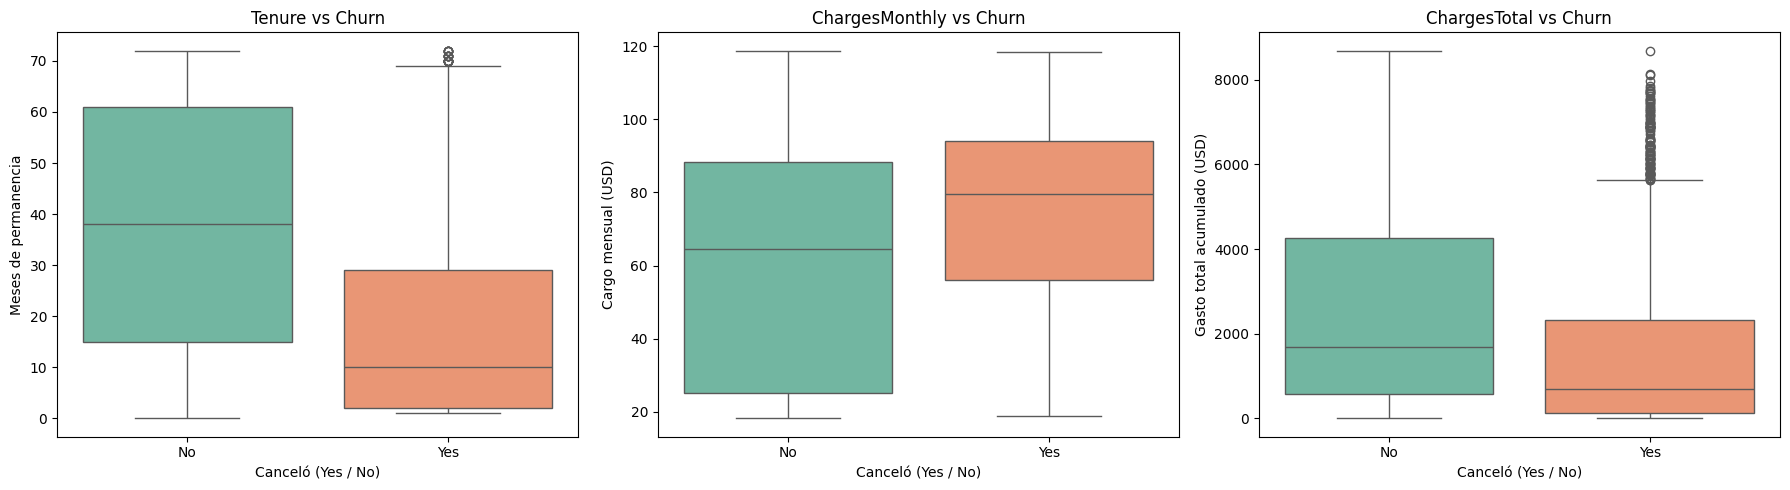

In [46]:
# Visualizamos mediante boxplots Tenure, ChargesMonthly y ChargesTotal según Churn.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x="Churn", y="Tenure", hue="Churn", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Tenure vs Churn")
axes[0].set_xlabel("Canceló (Yes / No)")
axes[0].set_ylabel("Meses de permanencia")

sns.boxplot(data=df, x="Churn", y="ChargesMonthly", hue="Churn", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("ChargesMonthly vs Churn")
axes[1].set_xlabel("Canceló (Yes / No)")
axes[1].set_ylabel("Cargo mensual (USD)")

sns.boxplot(data=df, x="Churn", y="ChargesTotal", hue="Churn", palette="Set2", legend=False, ax=axes[2])
axes[2].set_title("ChargesTotal vs Churn")
axes[2].set_xlabel("Canceló (Yes / No)")
axes[2].set_ylabel("Gasto total acumulado (USD)")

plt.tight_layout()
plt.show()


## 2.4 Análisis de variables categóricas vs Churn

In [47]:
# Calculamos la tasa de cancelación por cada categoría
categorical_cols = df.select_dtypes(include=["object"]).columns.drop("Churn")

for col in categorical_cols:
    print(f"\n📌 Variable: {col}")
    display(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)



📌 Variable: CustomerID


Churn,No,Yes
CustomerID,,
0002-ORFBO,100.0,0.0
0003-MKNFE,100.0,0.0
0004-TLHLJ,0.0,100.0
0011-IGKFF,0.0,100.0
0013-EXCHZ,0.0,100.0
...,...,...
9987-LUTYD,100.0,0.0
9992-RRAMN,0.0,100.0
9992-UJOEL,100.0,0.0



📌 Variable: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



📌 Variable: SeniorCitizen


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



📌 Variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



📌 Variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


## 2.5 Chi-cuadrado: ranking de importancia categórica

In [48]:
# Medimos la asociación estadística de cada variable con Churn mediante Chi2.
df_rank = df.copy()
df_rank["Churn"] = df_rank["Churn"].map({"Yes": 1, "No": 0})
cat_cols_rank = df_rank.select_dtypes(include=["object"]).columns

le = LabelEncoder()
for col in cat_cols_rank:
    df_rank[col] = le.fit_transform(df_rank[col])

X_cat = df_rank[cat_cols_rank]
y_rank = df_rank["Churn"]

chi_scores, p_values = chi2(X_cat, y_rank)

chi_df = pd.DataFrame({
    "Variable": cat_cols_rank,
    "Chi2 Score": chi_scores,
    "p-value": p_values
}).sort_values(by="Chi2 Score", ascending=False)

# Excluimos CustomerID: identificador único, sin valor predictivo.
chi_df = chi_df[chi_df["Variable"] != "CustomerID"]

display(chi_df)


,Variable,Chi2 Score,p-value
14,Contract,1115.780167,1.227941e-244
8,OnlineSecurity,147.295858,6.761696e-34
11,TechSupport,135.559783,2.490549e-31
2,SeniorCitizen,134.351545,4.576959e-31
4,Dependents,133.036443,8.876729e-31
15,PaperlessBilling,105.680863,8.661987e-25
3,Partner,82.412083,1.104764e-19
16,PaymentMethod,58.492250,2.040933e-14
9,OnlineBackup,31.217694,2.306541e-08
10,DeviceProtection,20.226662,6.878750e-06


In [49]:
# Filtramos y mostramos solo las variables con significancia estadística (p < 0.05).
print("\n✅ Variables significativas:")
display(chi_df[chi_df["p-value"] < 0.05])


✅ Variables significativas:


,Variable,Chi2 Score,p-value
14,Contract,1115.780167,1.227941e-244
8,OnlineSecurity,147.295858,6.761696e-34
11,TechSupport,135.559783,2.490549e-31
2,SeniorCitizen,134.351545,4.576959e-31
4,Dependents,133.036443,8.876729e-31
15,PaperlessBilling,105.680863,8.661987e-25
3,Partner,82.412083,1.104764e-19
16,PaymentMethod,58.492250,2.040933e-14
9,OnlineBackup,31.217694,2.306541e-08
10,DeviceProtection,20.226662,6.878750e-06


# 🔷 CAP 3 — Pre-procesamiento
Aplicamos todas las transformaciones sobre el dataframe

## 3.1 Eliminamos columnas irrelevantes

In [50]:
# Eliminamos columnas irrelevantes, duplicadas y con multicolinealidad.
# - CustomerID: identificador único, sin valor predictivo.
# - Gender, PhoneService: sin significancia estadística (p > 0.05 en chi²).
# - ChargesDaily: duplicado exacto de ChargesMonthly / 30 (correlación = 1.00).
# - ChargesTotal: combinación lineal de ChargesMonthly × Tenure → multicolinealidad.
df = df.drop(columns=['CustomerID', 'Gender', 'PhoneService',
                       'ChargesDaily', 'ChargesTotal'])


## 3.2 Unificamos categorías redundantes en servicios de internet

In [51]:
# Unificamos "No internet service" → "No" para simplificar las categorías.
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in cols_to_fix:
    df[col] = df[col].replace({'No internet service': 'No'})


## 3.3 Verificamos que no haya valores nulos tras los cambios

In [52]:
# Verificamos que no haya valores nulos tras los cambios.
print(df.isnull().sum())

Churn               0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
ChargesMonthly      0
dtype: int64


## 3.4 Mapeamos la variable objetivo Churn a binario

In [53]:
# Mapeamos Churn a binario (Yes→1, No→0) y confirmamos el dataframe final.
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df.head()

,Churn,SeniorCitizen,Partner,Dependents,Tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
0,0,No,Yes,Yes,9,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6
1,0,No,No,No,9,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9
2,1,No,No,No,4,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9
3,1,Yes,Yes,No,13,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0
4,1,Yes,Yes,No,3,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9


#🔷 CAP 4 - SPLIT: División en entrenamiento y prueba

In [54]:
# Separamos features (X) y variable objetivo (y)
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [55]:
# Dividimos en 80% entrenamiento y 20% prueba; estratificamos por Churn
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [56]:
# Aplicamos One-Hot Encoding tras el split para evitar data leakage
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test,  drop_first=True)

In [57]:
# Alineamos las columnas de test con las de entrenamiento.
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [58]:
# Estandarizamos columnas numéricas; ajustamos en train y transformamos test
scaler = StandardScaler()
num_cols = ['Tenure', 'ChargesMonthly']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

# Verificamos la proporción de clases en entrenamiento.
print("Proporción de clases en y_train:")
print(y_train.value_counts(normalize=True) * 100)

X_train.info()


Proporción de clases en y_train:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64
<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3793 to 5679
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Tenure                                 5634 non-null   float64
 1   ChargesMonthly                         5634 non-null   float64
 2   SeniorCitizen_Yes                      5634 non-null   bool   
 3   Partner_Yes                            5634 non-null   bool   
 4   Dependents_Yes                         5634 non-null   bool   
 5   MultipleLines_Yes                      5634 non-null   bool   
 6   InternetService_Fiber optic            5634 non-null   bool   
 7   InternetService_No                     5634 non-null   bool   
 8   OnlineSecurity_Yes                     5634 non-null   bool   
 9   OnlineBackup_Yes                       5

### 📐 Justificación de Normalización y Selección de Modelos

Antes de entrenar los modelos, aplicamos **estandarización** (`StandardScaler`)
únicamente sobre las variables numéricas `Tenure` y `ChargesMonthly`.

**¿Por qué es necesario para Regresión Logística?**
La Regresión Logística optimiza sus coeficientes internamente usando gradiente.
Si una variable tiene valores entre 0 y 72 (Tenure) y otra entre 18 y 118
(ChargesMonthly), el modelo podría darle más importancia a la de mayor magnitud
simplemente por su escala, no por su relevancia real.
Al estandarizar, ambas quedan en la misma escala (media=0, desviación=1),
permitiendo que el modelo compare las variables de forma justa.

**¿Por qué NO es necesario para Random Forest y XGBoost?**
Estos modelos toman decisiones basadas en **umbrales** (ej: "¿Tenure > 24?"),
no en distancias ni en magnitudes absolutas. Da igual si Tenure está en meses
o en años: el modelo encuentra el umbral óptimo de todas formas.
Por eso no requieren estandarización.

**Modelos seleccionados:**
| Modelo | Tipo | Requiere normalización |
|--------|------|----------------------|
| Reg. Logística estándar | Lineal | ✅ Sí |
| Reg. Logística balanceada | Lineal + balanceo | ✅ Sí |
| Random Forest | Árboles (Bagging) | ❌ No |
| XGBoost | Árboles (Boosting) | ❌ No |

Se eligió **XGBoost** en lugar de KNN o SVM porque es más robusto ante
datos desbalanceados (parámetro `scale_pos_weight`), más rápido en datasets
tabulares medianos, e igual de interpretable mediante importancia de variables.

# 🔷 CAP 5 - Entrenamiento
ENTRENAMIENTO DE MODELOS

### Modelo 1: Regresión Logística estándar

In [59]:
# Entrenamos la Regresión Logística estándar
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

### Modelo 2: Regresión Logística con clase balanceada

In [60]:
# Entrenamos la Regresión Logística con balanceo de clases
log_model_bal = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_model_bal.fit(X_train, y_train)
y_pred_log_bal = log_model_bal.predict(X_test)

### Modelo 3: Random Forest

In [61]:
# Entrenamos el Random Forest; no requiere normalización al basarse en árboles.
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

### Modelo 4: XGBoost


In [62]:
# Calculamos el ratio de clases para el parámetro scale_pos_weight de XGBoost.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Clases en y_train → No: {(y_train==0).sum()} | Yes: {(y_train==1).sum()}")
print(f"scale_pos_weight calculado: {scale_pos_weight:.4f}")

Clases en y_train → No: 4139 | Yes: 1495
scale_pos_weight calculado: 2.7686


In [63]:
# Entrenamos XGBoost con compensación dinámica del desbalance de clases.
xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight,
                           random_state=42,
                           eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)


# 🔷 CAP 6 — Evaluación
EVALUACIÓN DE MODELOS

### 6.1 Classification Reports

In [64]:
print("=" * 50)
print("Modelo 1 — Regresión Logística (estándar)")
print("=" * 50)
print(classification_report(y_test, y_pred_log, target_names=["No", "Yes"]))

Modelo 1 — Regresión Logística (estándar)
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [65]:
print("=" * 50)
print("Modelo 2 — Regresión Logística (balanceada)")
print("=" * 50)
print(classification_report(y_test, y_pred_log_bal, target_names=["No", "Yes"]))

Modelo 2 — Regresión Logística (balanceada)
              precision    recall  f1-score   support

          No       0.91      0.73      0.81      1035
         Yes       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



In [66]:
print("=" * 50)
print("Modelo 3 — Random Forest")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=["No", "Yes"]))

Modelo 3 — Random Forest
              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1035
         Yes       0.63      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



In [67]:
print("=" * 50)
print("Modelo 4 — XGBoost")
print("=" * 50)
print(classification_report(y_test, y_pred_xgb, target_names=["No", "Yes"]))

Modelo 4 — XGBoost
              precision    recall  f1-score   support

          No       0.87      0.78      0.82      1035
         Yes       0.52      0.68      0.59       374

    accuracy                           0.75      1409
   macro avg       0.70      0.73      0.70      1409
weighted avg       0.78      0.75      0.76      1409



## 6.2 Matrices de Confusión

In [68]:
# Definimos una función para graficar matrices de confusión.
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.xticks([0, 1], ["No", "Yes"])
    plt.yticks([0, 1], ["No", "Yes"])
    plt.tight_layout()
    plt.show()


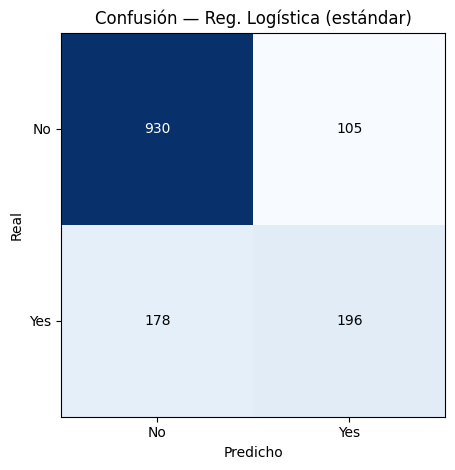

In [69]:
plot_cm(y_test, y_pred_log,     "Confusión — Reg. Logística (estándar)")

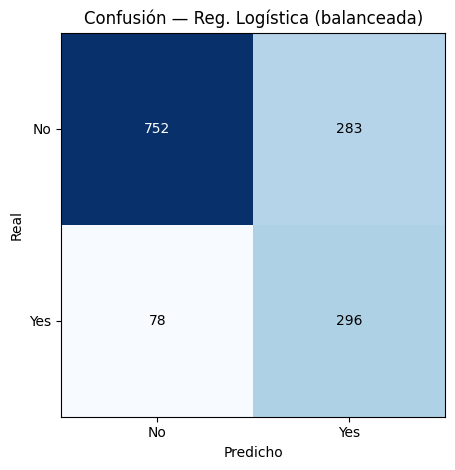

In [70]:
plot_cm(y_test, y_pred_log_bal, "Confusión — Reg. Logística (balanceada)")

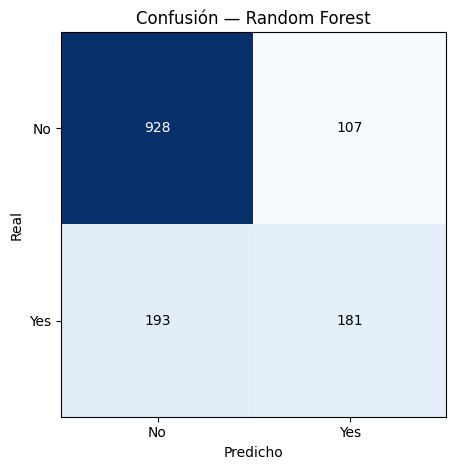

In [71]:
plot_cm(y_test, y_pred_rf,      "Confusión — Random Forest")

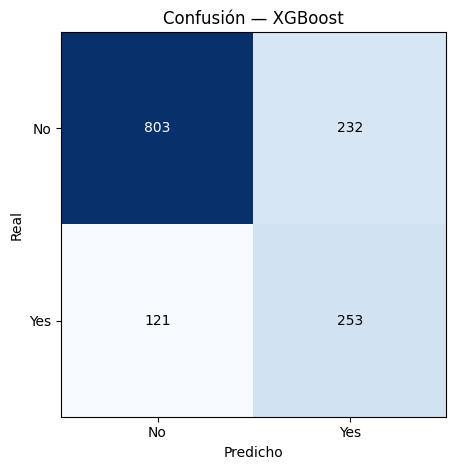

In [72]:
plot_cm(y_test, y_pred_xgb,     "Confusión — XGBoost")

## 📊 Análisis Comparativo de Modelos

| Modelo                        | Accuracy | Precision (Yes) | Recall (Yes) | F1 (Yes) |
|-------------------------------|----------|-----------------|--------------|----------|
| Reg. Logística (estándar)     |   0.80   |      0.65       |     0.52     |   0.58   |
| Reg. Logística (balanceada)   |   0.74   |      0.51       |     0.79     |   0.62   |
| Random Forest                 |   0.79   |      0.63       |     0.48     |   0.55   |
| XGBoost                       |   0.75   |      0.52       |     0.68     |   0.59   |

**Métrica clave: Recall (Yes)**
En churn, el error más costoso es NO detectar a un cliente que va a cancelar.
Por eso priorizamos Recall sobre Accuracy.

**✅ Mejor modelo: Reg. Logística Balanceada** → Recall (Yes) = 0.79

**Lectura de matrices de confusión:**
- Reg. Logística estándar: 196 detectados, **178 escaparon**
- Reg. Logística balanceada: **296 detectados**, 78 escaparon
- Random Forest: 181 detectados, **193 escaparon**
- XGBoost: 253 detectados, 121 escaparon

---

## ⚠️ Diagnóstico de Overfitting / Underfitting

### Random Forest → Overfitting leve
**Síntoma:** Accuracy alta (0.79) pero Recall (Yes) bajo (0.48).
El modelo aprende bien el patrón mayoritario (No-churn) pero no generaliza
bien a la clase minoritaria en datos nuevos.

**Causas probables:**
- Árboles demasiado profundos (parámetro `max_depth` sin límite por defecto).
- `n_estimators=100` puede ser excesivo para este dataset, memorizando ruido.

**Ajustes recomendados:**
```python
rf_model = RandomForestClassifier(
    max_depth=10,          # limita la profundidad de cada árbol
    min_samples_leaf=20,   # exige al menos 20 muestras por hoja
    class_weight='balanced', # compensa el desbalance de clases
    random_state=42
)
```

---

### Reg. Logística estándar → Underfitting parcial en clase "Yes"
**Síntoma:** Recall (Yes) = 0.52 — deja escapar casi la mitad de los churns.
El modelo no penaliza suficientemente los errores en la clase minoritaria,
priorizando la Accuracy global sobre la detección del churn.

**Causas probables:**
- Sin `class_weight`, ambas clases reciben el mismo peso durante el entrenamiento.
- El desbalance 73.5% / 26.5% sesga la frontera de decisión hacia "No".

**Ajustes recomendados:**
- Opción A (ya implementada): `class_weight='balanced'` → Modelo 2.
- Opción B: Reducir el umbral de decisión (`predict_proba > 0.35` en lugar de 0.5).
- Opción C: Aumentar regularización (`C=0.1`) para simplificar la frontera.

---

### Reg. Logística Balanceada y XGBoost → Comportamiento equilibrado ✅
Ambos modelos compensan el desbalance explícitamente (`class_weight` y
`scale_pos_weight`) logrando un trade-off aceptable entre Precision y Recall
sin señales claras de over ni underfitting.

> 🔎 Ver Cap 7 para el análisis profundo de variables y conclusión estratégica.


# 🔷 CAP 7 — Interpretación y Conclusiones

## 7.1 IMPORTANCIA DE VARIABLES POR MODELO

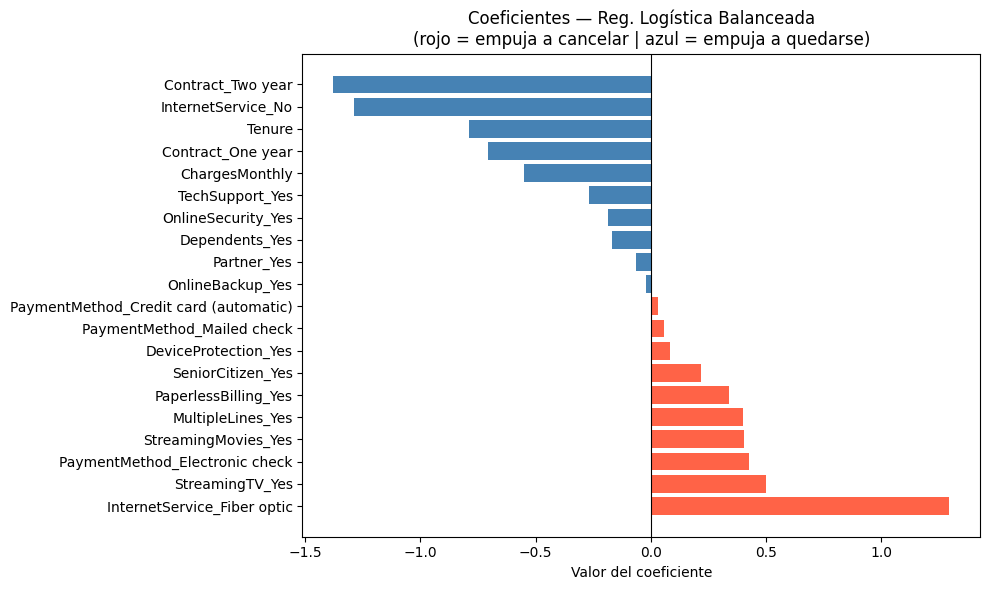

In [73]:
# Graficamos los coeficientes de la Regresión Logística Balanceada.
import pandas as pd
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": log_model_bal.coef_[0]
}).sort_values("Coeficiente", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(coef_df["Variable"], coef_df["Coeficiente"],
         color=["tomato" if c > 0 else "steelblue" for c in coef_df["Coeficiente"]])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Coeficientes — Reg. Logística Balanceada\n(rojo = empuja a cancelar | azul = empuja a quedarse)")
plt.xlabel("Valor del coeficiente")
plt.tight_layout()
plt.show()


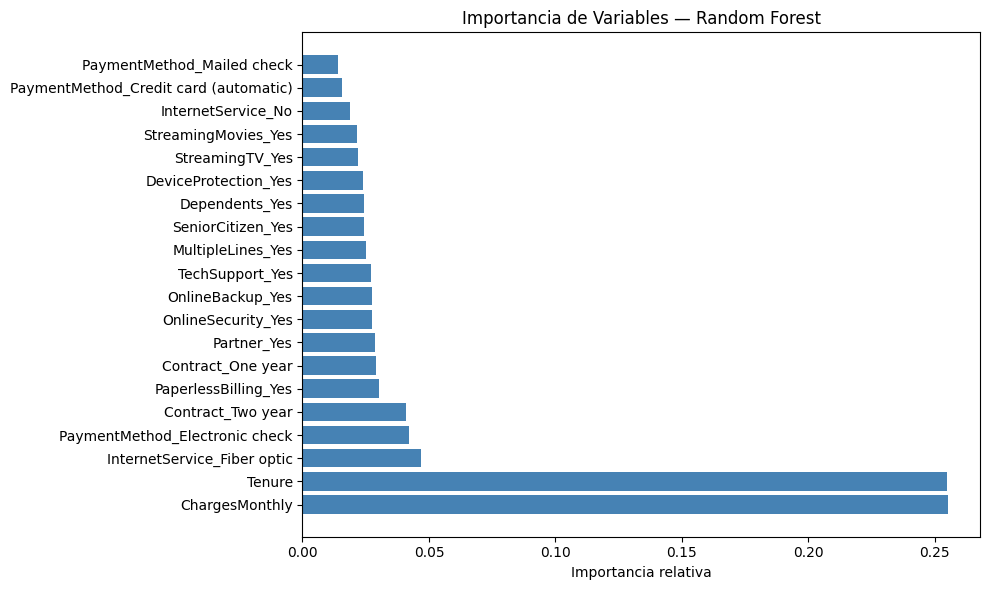

In [74]:
# Graficamos la importancia de variables del Random Forest.
feat_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": rf_model.feature_importances_
}).sort_values("Importancia", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_df["Variable"], feat_df["Importancia"], color="steelblue")
plt.title("Importancia de Variables — Random Forest")
plt.xlabel("Importancia relativa")
plt.tight_layout()
plt.show()


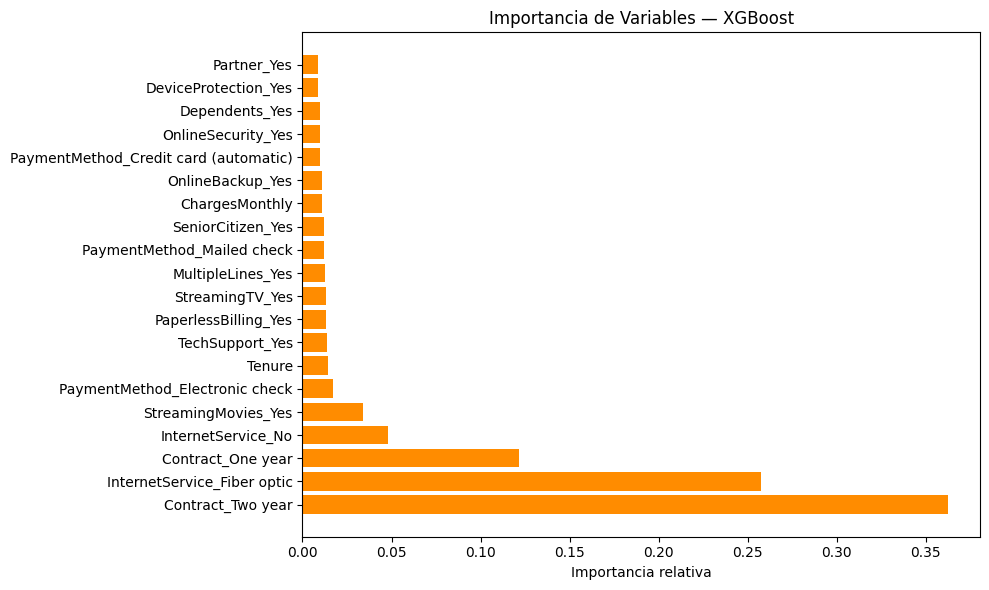

In [75]:
# Graficamos la importancia de variables del XGBoost
xgb_feat_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": xgb_model.feature_importances_
}).sort_values("Importancia", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(xgb_feat_df["Variable"], xgb_feat_df["Importancia"], color="darkorange")
plt.title("Importancia de Variables — XGBoost")
plt.xlabel("Importancia relativa")
plt.tight_layout()
plt.show()


## 7.2 Conclusión

## 📋Informe Final y Conclusión Estratégica

Este informe sintetiza los hallazgos del análisis exploratorio, la selección
de variables y el rendimiento de los cuatro modelos entrenados, con el objetivo
de identificar los factores que más influyen en la cancelación de clientes
y proponer acciones concretas de retención para Telecom X.

---

### 🔍 ¿Qué aprendimos de los datos antes de modelar?

**Matriz de correlación:**
- `Tenure` tiene correlación **negativa (-0.35)** con Churn: a más tiempo
  en la empresa, menos probabilidad de cancelar. Es la variable numérica
  más relevante para predecir fidelidad.
- `ChargesDaily` tiene correlación **perfecta (1.00)** con `ChargesMonthly`
  porque es exactamente `MonthlyCharges / 30` → información 100% duplicada.
  Por eso `ChargesDaily` fue eliminada.
- `ChargesTotal` ≈ `ChargesMonthly × Tenure`: no es un duplicado exacto,
  sino una **combinación lineal** de dos variables ya presentes. Mantenerla
  introduciría multicolinealidad, inflaría algunos coeficientes y no
  aportaría información que el modelo no capture ya separadamente.
  Por eso también fue eliminada.
- `ChargesMonthly` tiene correlación positiva leve (0.19) con Churn:
  pagar más se asocia levemente con mayor cancelación en el análisis univariado.

**Boxplots (Tenure, ChargesMonthly y ChargesTotal vs Churn):**
- Clientes que cancelaron tienen mediana de permanencia de apenas
  **~10 meses** vs **~38 meses** de los que se quedaron.
  Los primeros meses son los más críticos para la retención.
- Clientes que cancelaron pagan en promedio **más caro (~$80/mes)**
  vs los que permanecen (~$65/mes). Pagar más sin percibir valor
  suficiente es un detonante claro de abandono.
- `ChargesTotal` confirma la relación con `Tenure`: clientes activos
  acumularon un gasto medio de **~$1.900**, mientras los que cancelaron
  apenas alcanzaron **~$500**. Es consecuencia directa de la corta
  permanencia, no una causa independiente, razón por la que fue
  eliminada del modelado para evitar multicolinealidad.

---

### 📊 ¿Qué variables importan más según cada modelo?

**Reg. Logística Balanceada (coeficientes):**

Variables que más **empujan a cancelar** (positivas):
- `InternetService_Fiber optic` → coeficiente ~1.3, el más alto.
  Tener fibra óptica es el factor individual más fuerte de cancelación.
- `StreamingTV_Yes` → coeficiente ~0.5
- `PaymentMethod_Electronic check` → coeficiente ~0.45
- `StreamingMovies_Yes`, `MultipleLines_Yes`, `PaperlessBilling_Yes`,
  `SeniorCitizen_Yes` → contribuyen moderadamente a la cancelación.

Variables que más **empujan a quedarse** (negativas):
- `Contract_Two year` → coeficiente ~-1.4, el protector más fuerte.
  Un contrato de 2 años es la barrera más efectiva contra el churn.
- `InternetService_No` → sin internet, casi no se cancela (~7% churn).
- `Tenure` → coeficiente ~-0.7: a más tiempo como cliente, menor riesgo de irse.
- `Contract_One year` → coeficiente ~-0.55, segundo contrato más protector.
- `ChargesMonthly` → coeficiente ~-0.5: al controlar por tipo de contrato
  e internet, un cargo mensual mayor se asocia con planes más completos
  que generan mayor vínculo con el servicio.
- `TechSupport_Yes`, `OnlineSecurity_Yes`, `Dependents_Yes`,
  `Partner_Yes` → reducen el riesgo de cancelación.

**Random Forest (importancia):**
- `ChargesMonthly` y `Tenure` dominan (~0.25 cada una).
  Cuánto paga y cuánto tiempo lleva son los factores clave para este modelo.
- `InternetService_Fiber optic` tercero (~0.05), seguido de
  `PaymentMethod_Electronic check` y `Contract_Two year`.

**XGBoost (importancia):**
- `Contract_Two year` domina (~0.37), muy por encima del resto.
- `InternetService_Fiber optic` segundo (~0.26).
- `Contract_One year` tercero (~0.12).
- `Tenure` y `ChargesMonthly` tienen importancia muy baja (<0.05),
  contrario a lo que muestra Random Forest. XGBoost concentra
  todo el peso predictivo en el tipo de contrato.

**¿Qué coincide entre los 3 modelos?**

| Factor de riesgo       | Reg. Logística    | Random Forest     | XGBoost           |
|------------------------|-------------------|-------------------|-------------------|
| Fiber optic            | ⭐⭐⭐ Muy alto   | ⭐⭐ Alto         | ⭐⭐⭐ Muy alto   |
| Contrato mensual       | ⭐⭐⭐ Muy alto   | ⭐⭐ Alto         | ⭐⭐⭐ Muy alto   |
| Electronic check       | ⭐⭐ Alto         | ⭐⭐ Alto         | ⭐ Moderado       |
| Tenure bajo            | ⭐⭐ Alto         | ⭐⭐⭐ Muy alto   | ⭐ Bajo           |
| ChargesMonthly         | 🔵 Protector (multivariado) | ⭐⭐⭐ Muy alto | ⭐ Bajo  |

---

### 🏆 Factores principales de cancelación

**1. Tipo de contrato — el factor más decisivo**
Clientes mes a mes cancelan ~43% vs solo 3% en contrato de 2 años.
Los tres modelos lo confirman. Sin compromiso de permanencia,
el cliente se va ante cualquier insatisfacción.

**2. Servicio Fiber optic — el servicio con más insatisfacción**
Tasa de churn ~42%, señalado con alto impacto en los tres modelos.
Probablemente relacionado con expectativas no cumplidas de calidad
o precio elevado respecto al valor percibido.

**3. Tenure bajo — los primeros meses son críticos**
Mediana de apenas ~10 meses entre quienes cancelan vs ~38 meses
entre quienes permanecen. El cliente que no encuentra valor rápido,
se va antes de consolidar el hábito de uso.

**4. Cargo mensual — comportamiento dual según el modelo**
Clientes que cancelan pagan ~$80/mes en promedio vs ~$65/mes los
que permanecen (boxplot y Random Forest confirman la correlación,
importancia 0.25). Sin embargo, la Regresión Logística muestra
el efecto contrario (coeficiente ~-0.5): al controlar por tipo de
contrato e internet, un cargo mensual alto señala planes más completos
que generan fidelidad. El verdadero riesgo no es el cargo mensual
de forma aislada, sino la combinación **contrato mes a mes + fibra
óptica + sin add-ons**: esa combinación produce churn.

**5. Pago por Electronic check — perfil de mayor riesgo**
~45% de cancelación, el más alto de todos los métodos.
Puede indicar clientes con menor compromiso o con
experiencia de pago más incómoda que los métodos automáticos.

**6. Sin servicios adicionales — menos valor, menos fidelidad**
Sin TechSupport: churn ~31% vs ~15% con soporte.
Sin OnlineSecurity: churn ~31% vs ~15% con seguridad.
Los add-ons aumentan el valor percibido y generan fidelidad.

---

### 🎯 Estrategias de Retención Recomendadas

**1. Migrar clientes de contrato mensual a largo plazo**
Ofrecer descuentos o beneficios al migrar a contrato anual o bianual,
especialmente en los primeros 3 meses, cuando el riesgo es máximo.

**2. Programa de bienvenida para clientes nuevos**
Con mediana de churn en ~10 meses, el onboarding es crítico.
Seguimiento proactivo y revisión de satisfacción en los meses 3, 6 y 9.

**3. Revisar urgentemente el servicio Fiber optic**
Con ~42% de churn y señalado por los tres modelos, es el segmento
más urgente. Auditar calidad del servicio y crear planes de
fidelización específicos para este grupo.

**4. Promover TechSupport y OnlineSecurity como add-ons**
Clientes con estos servicios cancelan la mitad.
Ofrecer prueba gratuita de 3 meses puede generar hábito
y reducir significativamente el churn.

**5. Incentivar migración desde Electronic check**
Ofrecer descuentos por cambiar a débito o crédito automático,
métodos con tasas de churn del ~16% vs ~45% del cheque electrónico.

---

### ✅ Modelo Recomendado para Producción

**Regresión Logística Balanceada**
- Detecta el **79% de los clientes que cancelarán** (Recall más alto)
- Solo deja escapar **78 de 374 churns reales** en el set de prueba
- Simple, rápida e interpretable: el equipo comercial puede entender
  directamente qué variables empujan a cada cliente hacia el churn
- Permite construir un **score de riesgo de churn** accionable
  por el área de retención sin necesidad de infraestructura compleja
